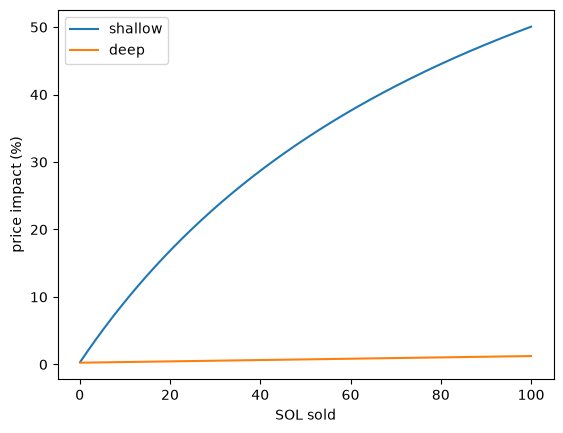

In [2]:
import matplotlib.pyplot as plt
from amm.constant_product import get_amount_out

pools = {"shallow": (100, 15_000), "deep": (10_000, 1_500_000)}
f = 0.0025
sizes = [i / 10 for i in range(1, 1001)]   # 0.1 to 100 SOL

for name, (x, y) in pools.items():
    spot = y / x                           # price before any trade (150 for both)
    impacts = []
    for dx in sizes:
        dy = get_amount_out(x, y, dx, f)   # USDT you receive
        execution = dy / dx                # what you actually got per SOL
        impact = 1 - execution / spot      # how much worse than spot
        impacts.append(impact * 100)       # as a percentage
    plt.plot(sizes, impacts, label=name)

plt.xlabel("SOL sold")
plt.ylabel("price impact (%)")
plt.legend()
plt.show()